In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import RobustScaler

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt

In [3]:
data = {
    "Gender":["Male","Female","Female","Male","Male"],
    "Education":["UG","PG","UG","PhD","PG"],
    "City":["Bangalore","Hyderabad","Chennai","Bangalore","Delhi"],
    "Age":[22,25,21,30,28],
    "Salary":[30000,50000,28000,80000,65000],
    "Purchased":[0,1,0,1,1]
}

df = pd.DataFrame(data)

df

,Gender,Education,City,Age,Salary,Purchased
0,Male,UG,Bangalore,22,30000,0
1,Female,PG,Hyderabad,25,50000,1
2,Female,UG,Chennai,21,28000,0
3,Male,PhD,Bangalore,30,80000,1
4,Male,PG,Delhi,28,65000,1


In [4]:
le = LabelEncoder()

df["Gender_Label"] = le.fit_transform(df["Gender"])

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label
0,Male,UG,Bangalore,22,30000,0,1
1,Female,PG,Hyderabad,25,50000,1,0
2,Female,UG,Chennai,21,28000,0,0
3,Male,PhD,Bangalore,30,80000,1,1
4,Male,PG,Delhi,28,65000,1,1


In [5]:
one_hot = pd.get_dummies(df["City"])

one_hot

,Bangalore,Chennai,Delhi,Hyderabad
0,True,False,False,False
1,False,False,False,True
2,False,True,False,False
3,True,False,False,False
4,False,False,True,False


In [6]:
df = pd.concat([df, one_hot], axis=1)

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label,Bangalore,Chennai,Delhi,Hyderabad
0,Male,UG,Bangalore,22,30000,0,1,True,False,False,False
1,Female,PG,Hyderabad,25,50000,1,0,False,False,False,True
2,Female,UG,Chennai,21,28000,0,0,False,True,False,False
3,Male,PhD,Bangalore,30,80000,1,1,True,False,False,False
4,Male,PG,Delhi,28,65000,1,1,False,False,True,False


In [7]:
oe = OrdinalEncoder(categories=[["UG","PG","PhD"]])

df["Education_Ordinal"] = oe.fit_transform(df[["Education"]])

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label,Bangalore,Chennai,Delhi,Hyderabad,Education_Ordinal
0,Male,UG,Bangalore,22,30000,0,1,True,False,False,False,0.0
1,Female,PG,Hyderabad,25,50000,1,0,False,False,False,True,1.0
2,Female,UG,Chennai,21,28000,0,0,False,True,False,False,0.0
3,Male,PhD,Bangalore,30,80000,1,1,True,False,False,False,2.0
4,Male,PG,Delhi,28,65000,1,1,False,False,True,False,1.0


In [8]:
scaler = StandardScaler()

df["Age_Standard"] = scaler.fit_transform(df[["Age"]])

df["Salary_Standard"] = scaler.fit_transform(df[["Salary"]])

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label,Bangalore,Chennai,Delhi,Hyderabad,Education_Ordinal,Age_Standard,Salary_Standard
0,Male,UG,Bangalore,22,30000,0,1,True,False,False,False,0.0,-0.933139,-1.028151
1,Female,PG,Hyderabad,25,50000,1,0,False,False,False,True,1.0,-0.058321,-0.029946
2,Female,UG,Chennai,21,28000,0,0,False,True,False,False,0.0,-1.224745,-1.127971
3,Male,PhD,Bangalore,30,80000,1,1,True,False,False,False,2.0,1.399708,1.467361
4,Male,PG,Delhi,28,65000,1,1,False,False,True,False,1.0,0.816497,0.718707


In [9]:
mm = MinMaxScaler()

df["Age_MinMax"] = mm.fit_transform(df[["Age"]])

df["Salary_MinMax"] = mm.fit_transform(df[["Salary"]])

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label,Bangalore,Chennai,Delhi,Hyderabad,Education_Ordinal,Age_Standard,Salary_Standard,Age_MinMax,Salary_MinMax
0,Male,UG,Bangalore,22,30000,0,1,True,False,False,False,0.0,-0.933139,-1.028151,0.111111,0.038462
1,Female,PG,Hyderabad,25,50000,1,0,False,False,False,True,1.0,-0.058321,-0.029946,0.444444,0.423077
2,Female,UG,Chennai,21,28000,0,0,False,True,False,False,0.0,-1.224745,-1.127971,0.000000,0.000000
3,Male,PhD,Bangalore,30,80000,1,1,True,False,False,False,2.0,1.399708,1.467361,1.000000,1.000000
4,Male,PG,Delhi,28,65000,1,1,False,False,True,False,1.0,0.816497,0.718707,0.777778,0.711538


In [10]:
rb = RobustScaler()

df["Age_Robust"] = rb.fit_transform(df[["Age"]])

df["Salary_Robust"] = rb.fit_transform(df[["Salary"]])

df

,Gender,Education,City,Age,Salary,Purchased,Gender_Label,Bangalore,Chennai,Delhi,Hyderabad,Education_Ordinal,Age_Standard,Salary_Standard,Age_MinMax,Salary_MinMax,Age_Robust,Salary_Robust
0,Male,UG,Bangalore,22,30000,0,1,True,False,False,False,0.0,-0.933139,-1.028151,0.111111,0.038462,-0.500000,-0.571429
1,Female,PG,Hyderabad,25,50000,1,0,False,False,False,True,1.0,-0.058321,-0.029946,0.444444,0.423077,0.000000,0.000000
2,Female,UG,Chennai,21,28000,0,0,False,True,False,False,0.0,-1.224745,-1.127971,0.000000,0.000000,-0.666667,-0.628571
3,Male,PhD,Bangalore,30,80000,1,1,True,False,False,False,2.0,1.399708,1.467361,1.000000,1.000000,0.833333,0.857143
4,Male,PG,Delhi,28,65000,1,1,False,False,True,False,1.0,0.816497,0.718707,0.777778,0.711538,0.500000,0.428571


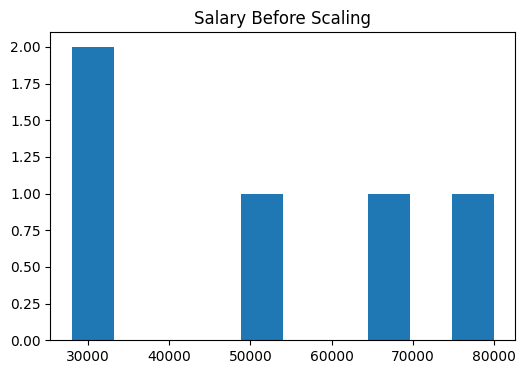

In [11]:
plt.figure(figsize=(6,4))

plt.hist(df["Salary"])

plt.title("Salary Before Scaling")

plt.show()

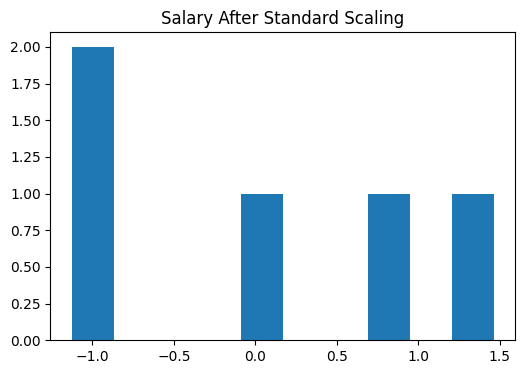

In [12]:
plt.figure(figsize=(6,4))

plt.hist(df["Salary_Standard"])

plt.title("Salary After Standard Scaling")

plt.show()

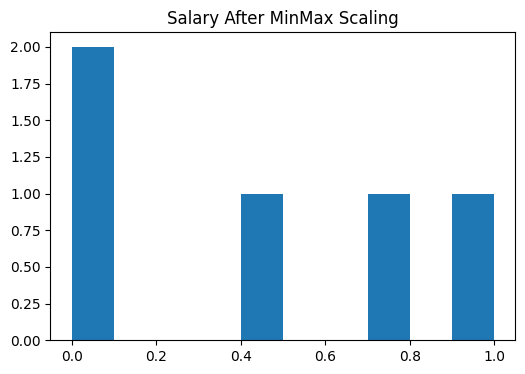

In [13]:
plt.figure(figsize=(6,4))

plt.hist(df["Salary_MinMax"])

plt.title("Salary After MinMax Scaling")

plt.show()

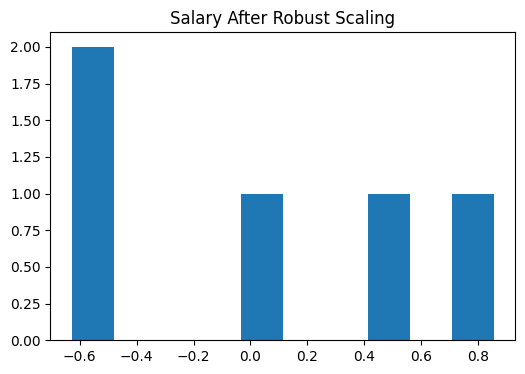

In [14]:
plt.figure(figsize=(6,4))

plt.hist(df["Salary_Robust"])

plt.title("Salary After Robust Scaling")

plt.show()

In [16]:
X = df[[
    "Age",
    "Salary",
    "Gender_Label",
    "Education_Ordinal"
]]

y = df["Purchased"]

In [17]:
selector = SelectKBest(score_func=f_classif, k="all")

selector.fit(X, y)

scores = pd.DataFrame({
    "Feature": X.columns,
    "Score": selector.scores_
})

scores.sort_values(by="Score", ascending=False)

,Feature,Score
0,Age,10.397468
1,Salary,10.322124
3,Education_Ordinal,9.600000
2,Gender_Label,0.085714
